####    Lab 2.1: nalyzing Historical Stock/Revenue Data and Building a Dashboard
#####   LiR
######  11-01-2026

In [132]:
!pip install yfinance
!pip install bs4
!pip install nbformat
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [133]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup

In [134]:
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

#####    Define Graphing Function

In [135]:
# The make_graph function has been modified to use Matplotlib for static graphs. Earlier, it used Plotly to generate interactive dashboards, which caused issues when uploading the notebook in the MARK assignment submission.
import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

In [136]:
#Question 1: Use yfinance to Extract Stock Data
#Using the Ticker function enter the ticker symbol of the stock 
# we want to extract data on to create a ticker object. 
# The stock is Tesla and its ticker symbol is TSLA.
import yfinance as yf
# Download historical data for a stock
tsla = yf.Ticker("TSLA")
tsla_data = tsla.history(period="max")
# Display the downloaded data
tsla_data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [137]:
#Using the ticker object and the function history extract stock information and save it in a dataframe named tesla_data. Set the period parameter to "max" so we get information for the maximum amount of time.
tesla_data = tsla.history(period="max")
tesla_data.head()


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [138]:
tesla_data.reset_index(inplace=True)
tesla_data.head(5)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [139]:
#Question 2: Use Webscraping to Extract Tesla Revenue Data
import requests

URL_webpage = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm'
headers = {
    "User-Agent": "Mozilla/5.0"
}
response = requests.get(URL_webpage) #, headers=headers)
#print(response.raise_for_status())
html_data = response.text
#html_data


In [140]:
#Parse the html data using beautiful_soup using parser i.e html5lib or html.parser.
#import pandas as pd
from bs4 import BeautifulSoup
soup = BeautifulSoup(html_data, 'html.parser')
#soup


In [141]:
#Using BeautifulSoup or the read_html function extract the table with Tesla Revenue and store it into a dataframe named tesla_revenue. The dataframe should have columns Date and Revenue.
import pandas as pd
tables = pd.read_html(URL_webpage)
tesla_revenue = tables[0]
# Оставляем нужные колонки
tesla_revenue.columns = ["Date", "Revenue"]
# Убираем строки с пустой выручкой
tesla_revenue = tesla_revenue[tesla_revenue["Revenue"] != "-"]

tesla_revenue.head()



,Date,Revenue
0,2021,"$53,823"
1,2020,"$31,536"
2,2019,"$24,578"
3,2018,"$21,461"
4,2017,"$11,759"


In [142]:
tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for row in soup.find_all("tr"):
    cols = row.find_all("td")
    if len(cols) == 2:
        date = cols[0].text.strip()
        revenue = cols[1].text.strip()
        if revenue != "":
            tesla_revenue.loc[len(tesla_revenue)] = [date, revenue]

tesla_revenue.head()

,Date,Revenue
0,2021,"$53,823"
1,2020,"$31,536"
2,2019,"$24,578"
3,2018,"$21,461"
4,2017,"$11,759"


In [143]:
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"",regex=True)
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]
print(tesla_revenue.head(5),"/n <-head---tail->")
#tesla_revenue.head(5)
# last 5 rows of Quartal
print(tesla_revenue.tail(5))

   Date Revenue
0  2021   53823
1  2020   31536
2  2019   24578
3  2018   21461
4  2017   11759 /n <-head---tail->
          Date Revenue
61  2010-09-30      31
62  2010-06-30      28
63  2010-03-31      21
64  2009-09-30      46
65  2009-06-30      27


In [144]:
#Question 3: Use yfinance to Extract Stock Data
import yfinance as yf
gme = yf.Ticker("GME")

In [145]:
#Using the ticker object and the function `history` extract stock information and save it in a dataframe named `gme_data`. Set the `period` parameter to ` "max" ` so we get information for the maximum amount of time.

gme_data =gme.history(period="max")

In [146]:
#Reset the index using the reset_index(inplace=True) function on the gme_data DataFrame and display the first five rows of the gme_data dataframe using the head function. Take a screenshot of the results and code from the beginning of Question 3 to the results below.
gme_data.reset_index(inplace=True)
gme_data.head(5)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716073,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [147]:
#Question 4: Use Webscraping to Extract GME Revenue Data\
#Use the requests library to download the webpage https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html. Save the text of the response as a variable named html_data_2
import requests
url_question_4 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html'
response = requests.get(url_question_4)
html_data_2 = response.text


In [148]:
#Parse the html data using beautiful_soup using parser i.e html5lib or html.parser.
from bs4 import BeautifulSoup
soup = BeautifulSoup(html_data_2, 'html.parser')

In [149]:
import pandas as pd
gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])
#---------------------

#print(soup.find("h1").text)
#table = soup.find("table")
#print(table.prettify()[:1000])
# прсомотр с данніми
tables = pd.read_html(html_data_2)
search_table = tables[1]
print(search_table.columns)
#print(len(tables))
#for idx,table_name in enumerate(tables):
#    print(f'index {idx} name {table_name}')
# только название колонок
#tables = pd.read_html(html_data_2)
#print(len(tables))
#for idx,table_name in enumerate(tables):
#    print(f'index {idx} name {table_name}')
##for i, t in enumerate(tables):
#    print(f"Table № {i} name {t} \n")
#    display(t.head())

#---------------------
# 1. Находим заголовок
#header = soup.find('h1',string="GameStop Revenue (USD Millions)")
#print(header)

# 2. Берём таблицу после заголовка
#table = header.find_next("table")
tables = soup.find_all("table")
search_table = tables[1]

# 3. Парсим ТОЛЬКО эту таблицу
#for row in soup.find_all("tr"):
for row in search_table.find_all("tr"):
    cols = row.find_all("td")
    if len(cols) == 2:
        date = cols[0].text.strip()
        revenue = cols[1].text.strip()

        if revenue != "" and revenue != "-":
            gme_revenue.loc[len(gme_revenue)] = [date, revenue]

gme_revenue.head()

Index(['GameStop Quarterly Revenue (Millions of US $)', 'GameStop Quarterly Revenue (Millions of US $).1'], dtype='object')


,Date,Revenue
0,2020-04-30,"$1,021"
1,2020-01-31,"$2,194"
2,2019-10-31,"$1,439"
3,2019-07-31,"$1,286"
4,2019-04-30,"$1,548"


In [150]:
# Remove $ and , from Revenue
gme_revenue["Revenue"] = (
    gme_revenue["Revenue"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

# Remove empty or null values
gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]
gme_revenue = gme_revenue.dropna()

# Optional: convert Revenue to numeric
gme_revenue["Revenue"] = gme_revenue["Revenue"].astype(int)

gme_revenue.head()

,Date,Revenue
0,2020-04-30,1021
1,2020-01-31,2194
2,2019-10-31,1439
3,2019-07-31,1286
4,2019-04-30,1548


In [151]:
gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


In [152]:
#Use the make_graph function to graph the Tesla Stock Data, also provide a title for the graph. Note the graph will only show data upto June 2021.
import matplotlib.pyplot as plt

#make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    #plt.tight_layout()
    plt.show()

IndentationError: unexpected indent (2270470900.py, line 5)

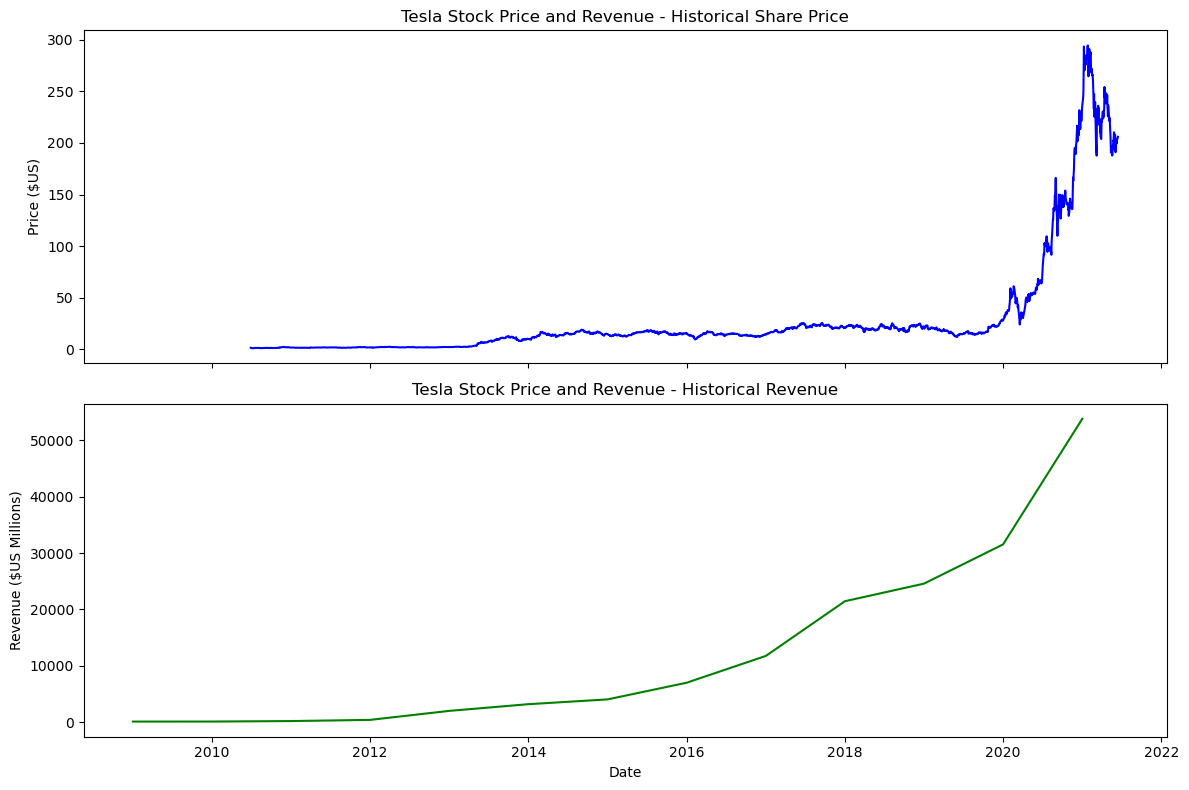

In [ ]:

tesla_revenue["Date"] = pd.to_datetime(tesla_revenue["Date"], errors="coerce")
make_graph(tesla_data, tesla_revenue, "Tesla Stock Price and Revenue")
